In [1]:
#import libraries and data     
import warnings 
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import RFECV
from collections import Counter
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

df_scaled = pd.read_csv('../data/heart_scaled.csv')
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']

Selected features by XGBoost (above average): ['thal', 'cp', 'ca', 'exang']


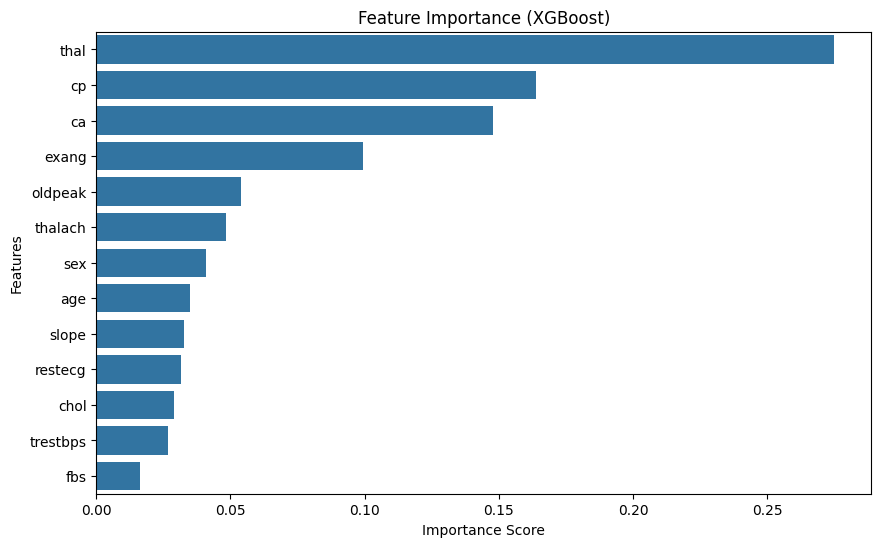

In [2]:
# XGBoost Feature Importance
xgb = XGBClassifier(random_state=42)
xgb.fit(X, y)
xgb_importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

avg_importance = xgb_importances.mean()
xgb_selected_features = xgb_importances[xgb_importances > avg_importance].index

print("Selected features by XGBoost (above average):", list(xgb_selected_features))
plt.figure(figsize=(10,6))
sns.barplot(x=xgb_importances, y=xgb_importances.index)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

best number for (k): 9
highest accuarcy: 0.842
selected feature: ['sex', 'cp', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


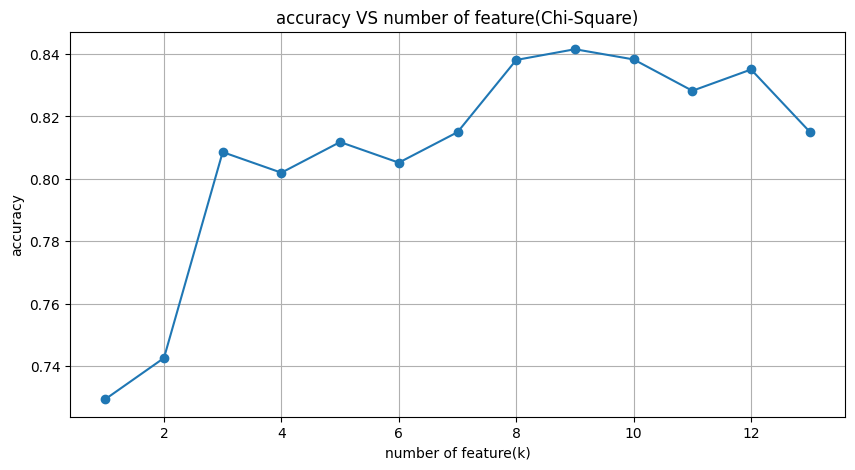

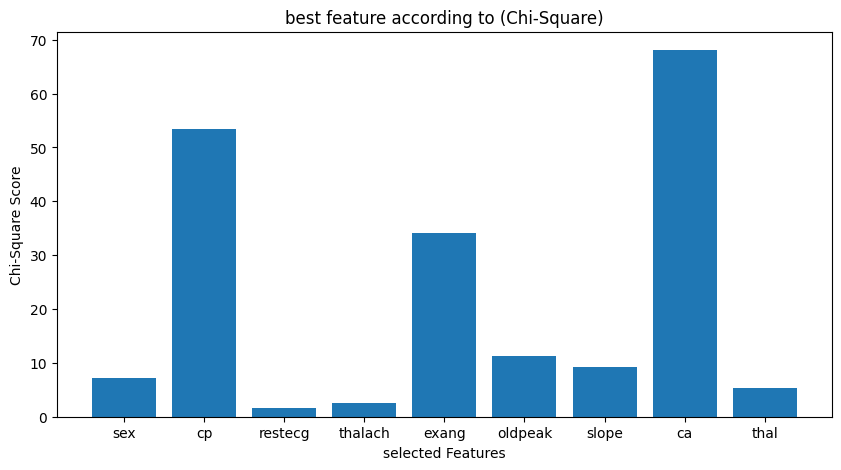

In [3]:
# chi square with Random Forest Classifier
best_score = 0
best_k = 1
best_features = None

scores_list = []
for k in range(1, X.shape[1] + 1):
    selector = SelectKBest(score_func=chi2, k=k)
    X_new = selector.fit_transform(X, y)
    score = cross_val_score(RandomForestClassifier(random_state=42), X_new, y, cv=5).mean()
    scores_list.append(score)
    if score > best_score:
        best_score = score
        best_k = k
        best_features = X.columns[selector.get_support()]

print(f"best number for (k): {best_k}")
print(f"highest accuarcy: {best_score:.3f}")
print("selected feature:", list(best_features))

plt.figure(figsize=(10,5))
plt.plot(range(1, X.shape[1] + 1), scores_list, marker='o')
plt.xlabel("number of feature(k)")
plt.ylabel("accuracy")
plt.title("accuracy VS number of feature(Chi-Square)")
plt.grid(True)
plt.show()

selector = SelectKBest(score_func=chi2, k=best_k)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
selected_scores = selector.scores_[selector.get_support()]

plt.figure(figsize=(10,5))
plt.bar(selected_features, selected_scores)
plt.xlabel("selected Features")
plt.ylabel("Chi-Square Score")
plt.title("best feature according to (Chi-Square)")
plt.show()

Optimal number of features: 10
Ranking of features: [1 1 1 1 3 4 2 1 1 1 1 1 1]
Selected features: ['age', 'sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


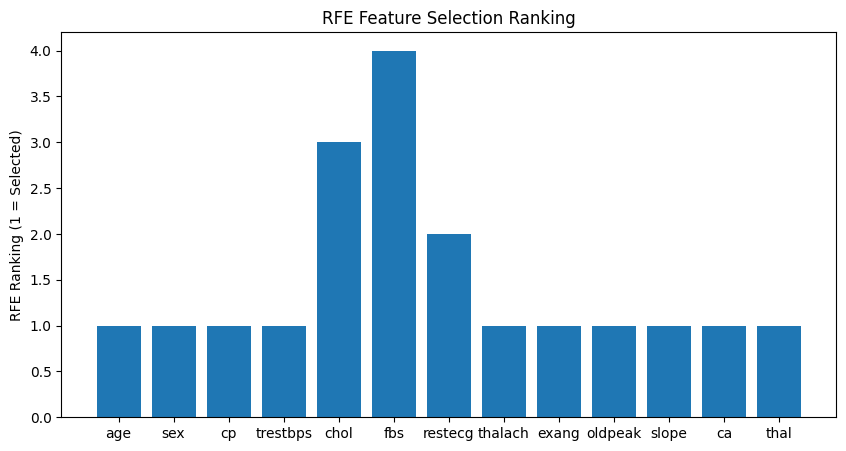

In [4]:
# RFE with Logistic Regression
model =LogisticRegression(random_state=42)
rfecv = RFECV(estimator=model, step=1, cv=5, scoring='accuracy')
rfecv.fit(X, y)

print("Optimal number of features:", rfecv.n_features_)
print("Ranking of features:", rfecv.ranking_)
print("Selected features:", list(X.columns[rfecv.support_]))
rfecv_features = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rfecv.ranking_,
    "Selected": rfecv.support_
})

plt.figure(figsize=(10,5))
plt.bar(rfecv_features['Feature'], rfecv_features['Ranking'])
plt.ylabel("RFE Ranking (1 = Selected)")
plt.title("RFE Feature Selection Ranking")
plt.show()


In [5]:
# Combine Results and evaluation based on logical funcion
final_features = set(xgb_selected_features) | set(best_features) & set(X.columns[rfecv.support_])
print("Final selected features:", list(final_features))

model=SVC(random_state=42)
model.fit(X[list(final_features)], y)
scores = cross_val_score(model, X[list(final_features)], y, cv=5)  
print("Cross-validation scores:", np.round(scores, 3))
print("Mean accuracy:", scores.mean())


Final selected features: ['thal', 'exang', 'ca', 'thalach', 'slope', 'oldpeak', 'cp', 'sex']
Cross-validation scores: [0.885 0.885 0.852 0.9   0.733]
Mean accuracy: 0.8512568306010928
